In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

In [66]:
FX=pd.read_csv("data/raw/us_equities.csv.gz")

df = pd.DataFrame(FX)
df.head()

,Unnamed: 0,^GSPC,GE,IBM,DIS,BA,CAT,AA,HPQ,DD,...,CTX,CTR,DYN,AIB,PCU,KIM,SFN,AMR,TCO,S
0,1,16.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,16.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,16.93,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,16.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,17.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
df.shape

(16291, 1054)

<Axes: >

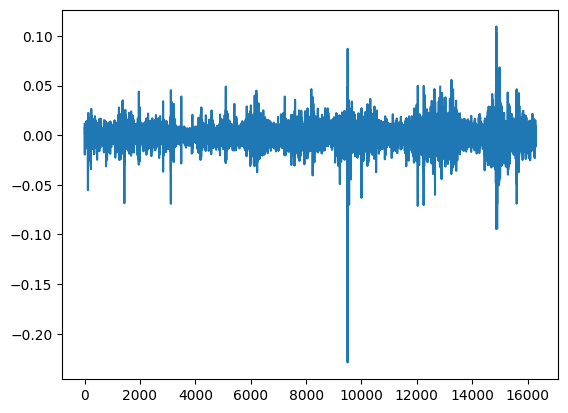

In [68]:
df["log_returns"]=np.log(df["^GSPC"]).diff()
df["log_returns"].plot()

In [69]:
NaN = df.isnull().sum(axis=1)
NaN_sorted=NaN.sort_values(ascending=False)
print(NaN_sorted)

8008     1053
0        1053
31       1052
30       1052
29       1052
         ... 
13936      33
13938      33
13846      33
13851      33
13826      33
Length: 16291, dtype: int64


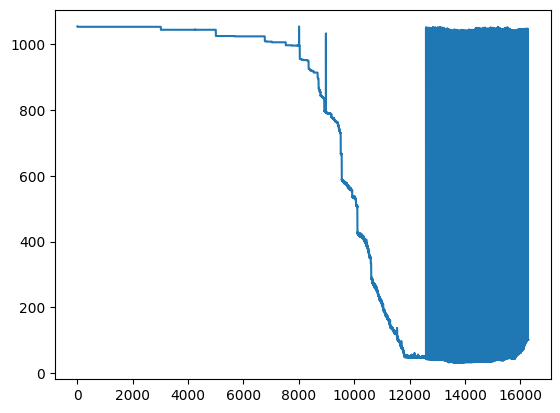

In [70]:
plt.plot(NaN)

In [71]:
GSPC_null=df["^GSPC"].isnull()
print(GSPC_null)
print(f"Nb of null values in ^GSPC: {GSPC_null.sum()}")

0        False
1        False
2        False
3        False
4        False
         ...  
16286    False
16287    False
16288    False
16289    False
16290    False
Name: ^GSPC, Length: 16291, dtype: bool
Nb of null values in ^GSPC: 136


In [72]:
exclude = df[GSPC_null].notnull()
exclude.head()

,Unnamed: 0,^GSPC,GE,IBM,DIS,BA,CAT,AA,HPQ,DD,...,CTR,DYN,AIB,PCU,KIM,SFN,AMR,TCO,S,log_returns
8008,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8979,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
12594,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
12619,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
12663,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [73]:
exclude_sum = exclude.sum()
exclude_sum_sorted = exclude_sum.sort_values(ascending=False)
print(exclude_sum_sorted)

Unnamed: 0    136
SOV           133
SGR           125
ABK           110
SUN           108
             ... 
CVX             0
PEG             0
FIF             0
CRY             0
TNL             0
Length: 1055, dtype: int64


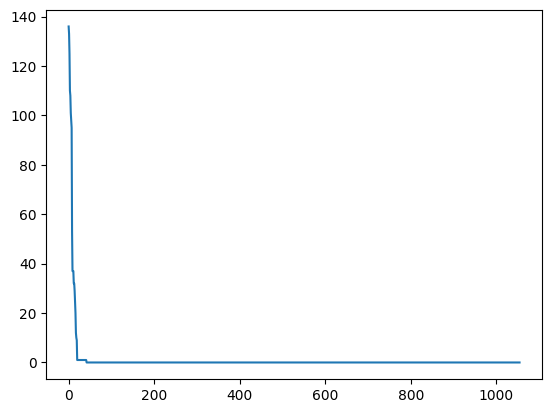

In [74]:
plt.plot(exclude_sum_sorted.values)

In [75]:
exclude_sum_col = exclude_sum[exclude_sum != 0]
print(exclude_sum_col.shape)

(42,)


In [76]:
df.drop(columns=exclude_sum_col.index, inplace=True)
df.shape

(16291, 1013)

In [81]:
GSPC_null_row = GSPC_null[GSPC_null == True]
df.drop(index=GSPC_null_row.index, inplace=True)
df.shape

(16155, 1013)

In [83]:
df["log_returns"]=np.log(df["^GSPC"]).diff()
df.head()

,^GSPC,GE,IBM,DIS,BA,CAT,AA,HPQ,DD,KO,...,CLP,CTX,CTR,DYN,AIB,KIM,SFN,TCO,S,log_returns
0,16.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,16.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011340
2,16.93,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004737
3,16.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002949
4,17.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005872


In [88]:
theta = 0.15
high_abs_log_ret = [df["log_returns"].abs() > theta]
print(high_abs_log_ret)

[0        False
1        False
2        False
3        False
4        False
         ...  
16286    False
16287    False
16288    False
16289    False
16290    False
Name: log_returns, Length: 16155, dtype: bool]


In [90]:
df["log_returns"] = df["log_returns"].clip(lower=-theta, upper=theta)

In [91]:
df["log_returns"].to_csv("data/clean/us-equities_log_returns.csv.gz")

In [93]:
df.to_parquet("data/clean/us-equities_log_returns.parquet", engine="fastparquet", index=False)

In [97]:
i = 0
alpha_vec=[]
nb_col_max = 2
for col in df.columns:
    i += 1
    abs_col = df[col].abs()
    myfit = powerlaw.Fit(abs_col)
    alpha_vec.append(myfit.alpha)
    if i > 5:
        break
mean_alpha = np.mean(alpha_vec)
print(f"Mean alpha: {mean_alpha}")

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit


c:\Users\raphe\AppData\Local\Programs\Python\Python313\Lib\site-packages\powerlaw.py:1151: RuntimeWarning: divide by zero encountered in scalar divide
  self.alpha = 1 + (self.n / sum(log(data/self.xmin)))
Not enough data. Returning nan


Not enough data. Returning nan


Calculating best minimal value for power law fit
Calculating best minimal value for power law fit


Not enough data. Returning nan


Calculating best minimal value for power law fit


Not enough data. Returning nan


Mean alpha: inf99%


Not enough data. Returning nan


In [ ]:
abs_log_ret = df["log_returns"].abs()
myfit = powerlaw.Fit(abs_log_ret)
print(myfit.alpha,myfit.xmin)
print(np.mean(abs_log_ret>myfit.xmin))
print(np.log10(np.max(abs_log_ret))/myfit.xmin)

Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating best minimal value for power law fit
4.142459010902316 0.020892805199872022
0.039244815846487154
-39.43504632634806
